<a href="https://colab.research.google.com/github/gabrielaugustavo/LLM/blob/main/aula6_retrieval_augmented_generation_rag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 6: Introdução a RAG (Retrieval-Augmented Generation)

Objetivos:

- Entender o pipeline completo de um sistema RAG
- Implementar:
  - Chunking
  - Geração de embeddings
  - Busca vetorial por similaridade
  - Geração de resposta condicionada ao contexto recuperado
- Analisar como a recuperação influencia a qualidade da resposta


Nesta aula vamos usar o seguinte roteiro prático:

1. Criar uma mini base de conhecimento (docs).
2. Fazer *chunking* (segmentação) para obter unidades recuperáveis.
3. Gerar embeddings e implementar uma busca vetorial simples.
4. Montar o *contexto* (augmentation) com os chunks mais relevantes.
5. Passar o contexto para um modelo gerador (generator) e obter uma resposta (*RAG completo*).


## 1) Setup do ambiente


In [112]:
# Se necessário, instale as seguintes dependências:
# !pip install -U sentence-transformers transformers torch scikit-learn numpy pandas matplotlib

import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch


## 2) Mini Base de Conhecimento


In [113]:
# Mini base de conhecimento (exemplo didático).
# Dica: substitua por trechos do seu domínio (FAQ, políticas, docs, etc.).

docs = [
    {
        "id": "doc1",
        "text": '''
Enfim o final da série chegou e me deixou arrebatada e emocionada. Um final cheio de amor e lembranças, perfeito para uma série tão emocionante e intensa. Mauricio era o último dos Lafaietes solteiro, mas Eleonora arrebatou seu coração, ainda que não estivesse nos seus planos.
'''
    },
    {
        "id": "doc2",
        "text": '''
Ele desde sempre soube o que queria e correu atrás para realizar os seus sonhos. Eleonora não foi uma mocinha fácil e dócil.
 Estou definitivamente de ressaca literária, os Lafaietes sempre terão um pedacinho do meu coração. Super recomendo. Os airbags reduzem o impacto em caso de colisão.
        '''
    },
    {
        "id": "doc3",
        "text": '''
       O combustivel fossil é feito de petroleo.
    O combustível pode ser gasolina, etanol, diesel ou eletricidade.
Etanol pode ser feito de cana de açucar e é um combustível.
Carros a combustão usam gasolina, etanol ou  diesel.
        '''
    }
]


## 3) Chunking (segmentação) - construção de contexto

Nesta aula, vamos usar sentenças como chunks (simples e didático).  
Em produção, você normalmente usa chunking por **tamanho** (tokens/caracteres) + **overlap**.


In [114]:
def split_sentences_pt(text: str) -> list[str]:
    # Segmentação simplificada (por ponto).
    return [s.strip() for s in text.split(".") if len(s.strip()) > 0]

rows = []
for doc in docs:
    sentences = split_sentences_pt(doc["text"])
    for sent in sentences:
        rows.append({
            "doc_id": doc["id"],
            "sentence": sent
        })

df = pd.DataFrame(rows)
df


,doc_id,sentence
0,doc1,Enfim o final da série chegou e me deixou arre...
1,doc1,"Um final cheio de amor e lembranças, perfeito ..."
2,doc1,"Mauricio era o último dos Lafaietes solteiro, ..."
3,doc2,Ele desde sempre soube o que queria e correu a...
4,doc2,Eleonora não foi uma mocinha fácil e dócil
5,doc2,"Estou definitivamente de ressaca literária, os..."
6,doc2,Super recomendo
7,doc2,Os airbags reduzem o impacto em caso de colisão
8,doc3,O combustivel fossil é feito de petroleo
9,doc3,"O combustível pode ser gasolina, etanol, diese..."


## 4) Gerar embeddings (Retriever, R do RAG)

Usaremos um modelo encoder-only do SentenceTransformers para gerar embeddings dos chunks.


In [115]:
model_emb = SentenceTransformer("all-MiniLM-L6-v2")

sentences = df["sentence"].tolist()
embeddings = model_emb.encode(sentences)

df["embedding"] = list(embeddings)
df.head()


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,doc_id,sentence,embedding
0,doc1,Enfim o final da série chegou e me deixou arre...,"[-0.0031773434, 0.059797563, -0.094297186, -0...."
1,doc1,"Um final cheio de amor e lembranças, perfeito ...","[-0.04596944, 0.08273779, 0.0065507325, 0.0003..."
2,doc1,"Mauricio era o último dos Lafaietes solteiro, ...","[-0.009468041, 0.055405643, -0.05020088, 0.042..."
3,doc2,Ele desde sempre soube o que queria e correu a...,"[-0.014030316, 0.05313905, -0.07287342, -0.069..."
4,doc2,Eleonora não foi uma mocinha fácil e dócil,"[0.036373697, 0.10634702, -0.008873318, -0.002..."


## 5) Busca vetorial por similaridade (R do RAG)

Implementação minimalista com similaridade cosseno.  
(Em produção, isso vai para um índice/banco vetorial: FAISS, Milvus, Pinecone, Weaviate, pgvector, etc.)


In [116]:
def retrieve(query: str, top_k: int = 3) -> pd.DataFrame:
    query_emb = model_emb.encode([query])
    matrix = np.vstack(df["embedding"].values)

    sims = cosine_similarity(query_emb, matrix)[0]
    top_idx = np.argsort(sims)[::-1][:top_k]

    results = df.iloc[top_idx].copy()
    results["score"] = sims[top_idx]
    return results

query = "Como funciona a autenticação?"
retrieve(query, top_k=3)


,doc_id,sentence,embedding,score
2,doc1,"Mauricio era o último dos Lafaietes solteiro, ...","[-0.009468041, 0.055405643, -0.05020088, 0.042...",0.511349
5,doc2,"Estou definitivamente de ressaca literária, os...","[0.09149341, 0.022932405, -0.06638643, 0.01797...",0.481723
3,doc2,Ele desde sempre soube o que queria e correu a...,"[-0.014030316, 0.05313905, -0.07287342, -0.069...",0.479134


## 6) Montando o contexto (Augmentation, A do RAG)

Agora agregamos os chunks recuperados em um bloco de texto que será injetado no prompt.


In [117]:
def build_context(query: str, top_k: int = 3) -> str:
    retrieved = retrieve(query, top_k)
    context = "\n".join(retrieved["sentence"].tolist())
    return context


context = build_context(query, top_k=3)
print(context)


Mauricio era o último dos Lafaietes solteiro, mas Eleonora arrebatou seu coração, ainda que não estivesse nos seus planos
Estou definitivamente de ressaca literária, os Lafaietes sempre terão um pedacinho do meu coração
Ele desde sempre soube o que queria e correu atrás para realizar os seus sonhos


## 7) Parte gerativa (Generation, G do RAG)

Aqui usamos um modelo causal pequeno para fins didáticos. Troque o distilgpt2 para o gemma 3 para melhores resultados.


In [118]:
model_name = "distilgpt2" # Modelo pequeno para teste rápido
#model_name = "google/gemma-3-270m" # De melhor qualidade, mas download de 0.5G

tokenizer = AutoTokenizer.from_pretrained(model_name)
model_gen = AutoModelForCausalLM.from_pretrained(model_name)

# distilgpt-2 não tem pad_token necessário para a geração
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 8) Pipeline RAG simples

1. Recupera chunks (Retriever)  
2. Monta contexto (Augmentation)  
3. Gera resposta condicionada (Generator)


In [127]:
def rag_answer(query: str, top_k: int = 3, max_tokens: int = 150) -> str:
    context = build_context(query, top_k)

    prompt = f"""Responda usando apenas o contexto abaixo.
Contexto:
{context}
Pergunta:
{query}
Resposta:
"""

    inputs = tokenizer(prompt, return_tensors="pt", padding=True, truncation=True)

    with torch.no_grad():
        outputs = model_gen.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=False,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id
        )

    answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return answer

print(rag_answer("qual o final da série", top_k=2, max_tokens=150))


Responda usando apenas o contexto abaixo.
Contexto:
Enfim o final da série chegou e me deixou arrebatada e emocionada
Um final cheio de amor e lembranças, perfeito para uma série tão emocionante e intensa
Pergunta:
qual o final da série
Resposta:
Enfim o final da série
Enfim o final da série
Enfim o final da série
Enfim o final da série
Enfim o final da série
Enfim o final da série
Enfim o final da série
Enfim o final da série
Enfim o final da série
Enfim o final da série
Enfim o final da série
Enfim o final da série
Enfim o final da série
Enfim o final da série
Enfim o final da série



## 9) Visualizando similaridade (conexão com Embeddings)

Vamos projetar os embeddings em 2D com PCA para observar agrupamentos.


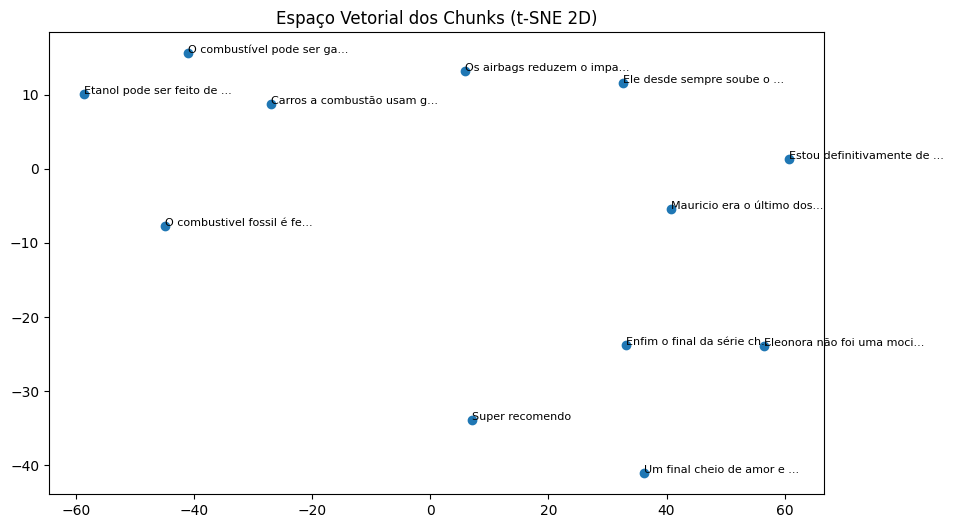

In [120]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE # Import TSNE
import matplotlib.pyplot as plt

X = np.vstack(df["embedding"].values)

# Use t-SNE instead of PCA
ts = TSNE(n_components=2, random_state=42, perplexity=5) # Added random_state for reproducibility and fixed perplexity
X2 = ts.fit_transform(X)

plt.figure(figsize=(10, 6))
plt.scatter(X2[:, 0], X2[:, 1])

for i, txt in enumerate(df["sentence"]):
    plt.annotate(txt[:25] + ("..." if len(txt) > 25 else ""), (X2[i, 0], X2[i, 1]), fontsize=8)

plt.title("Espaço Vetorial dos Chunks (t-SNE 2D)") # Update title
plt.show()

## 10) Experimentos

Tente rodar as células abaixo e discutir os resultados.

- O que acontece se `top_k = 1`?
- E se aumentarmos para `top_k = 5`?
- Faça uma pergunta fora do domínio da base (para ver como o sistema se comporta).
- Modifique os documentos e observe o impacto na resposta.
